# Import

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Attention Spread Heatmap
Visualize the average fraction of attention landing on image tokens for every layer/head pair using the aggregated `attention_spread_summary.json` output.

In [16]:
# Plot 32x32 head grid of average image-attention fraction
summary_path = "attention_distribution_2000.json"
with open(summary_path, "r", encoding="utf-8") as f:
    attention_summary = json.load(f)

overall_stats = attention_summary.get("overall", {})
print(f"Fraction of attention placed on image tokens on average by a head: {overall_stats.get('image_fraction', 0.0):.3f}")
print(f"Fraction of attention placed on text tokens on average by a head: {overall_stats.get('text_fraction', 0.0):.3f}")
head_image_map = overall_stats.get("head_image_fraction_map", {})
head_text_map = overall_stats.get("head_text_fraction_map", {})

def _layer_sort_key(layer_name):
    try:
        return int(str(layer_name).split("_")[-1])
    except ValueError:
        return layer_name

if isinstance(head_image_map, dict):
    layer_keys = sorted(head_image_map.keys(), key=_layer_sort_key)
    head_image_data = np.asarray([head_image_map[k] for k in layer_keys], dtype=float)
else:
    layer_keys = []
    head_image_data = np.asarray(head_image_map, dtype=float)

if isinstance(head_text_map, dict) and layer_keys:
    head_text_data = np.asarray([head_text_map.get(k, [np.nan] * head_image_data.shape[1]) for k in layer_keys], dtype=float)
else:
    head_text_data = np.asarray(head_text_map, dtype=float)

if head_text_data.size == 0:
    head_text_data = np.clip(1.0 - head_image_data, 0.0, 1.0)

if head_text_data.shape != head_image_data.shape:
    raise ValueError("Image/text head maps have mismatched shapes. Regenerate attention_spread_summary.json.")

highlight_threshold = 0.35

if head_image_data.size == 0:
    raise ValueError("No head-level attention data found in attention_spread_summary.json. Did you run analyse_attention_distribution.py?")

Fraction of attention placed on image tokens on average by a head: 0.165
Fraction of attention placed on text tokens on average by a head: 0.835


Loaded head image fraction map with shape: (32, 32)
Heads >= 35% image attention: 129/1024


/tmp/ipykernel_2293622/637029670.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=False)


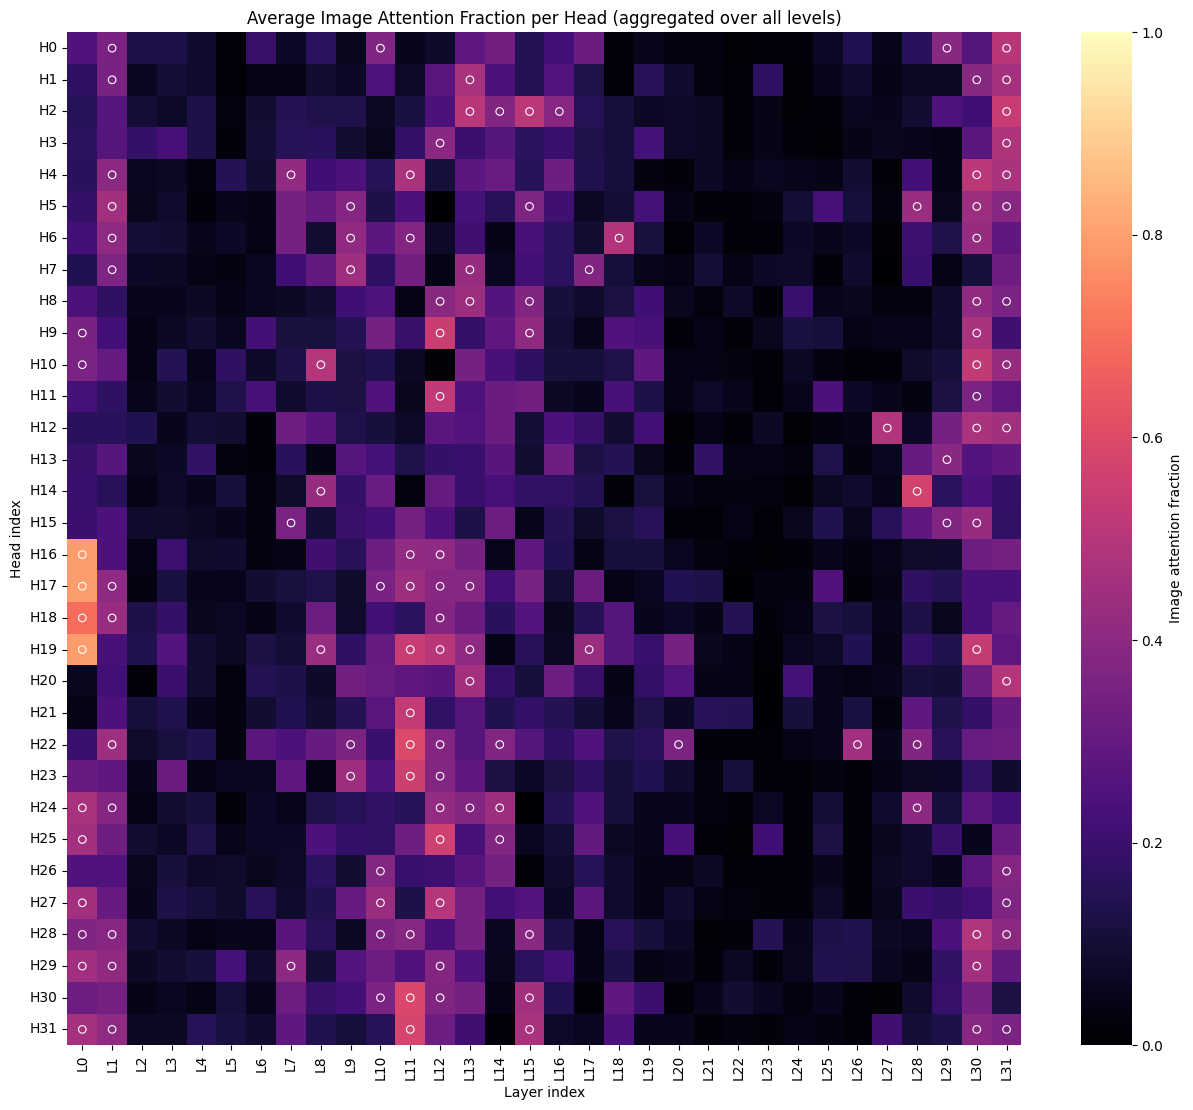

In [17]:
num_layers, num_heads = head_image_data.shape
print(f"Loaded head image fraction map with shape: {head_image_data.shape}")

highlight_mask = head_image_data >= highlight_threshold
num_highlighted = int(highlight_mask.sum())
total_heads = head_image_data.size
print(f"Heads >= {highlight_threshold:.0%} image attention: {num_highlighted}/{total_heads}")

plot_data = head_image_data.T  # rows=heads, cols=layers

plt.figure(figsize=(min(18, num_layers * 0.4), min(14, num_heads * 0.35)))
ax = sns.heatmap(
    plot_data,
    cmap="magma",
    vmin=0.0,
    vmax=1.0,
    cbar_kws={"label": "Image attention fraction"},
)
ax.set_xticks(np.arange(num_layers) + 0.5)
ax.set_xticklabels([f"L{idx}" for idx in range(num_layers)], rotation=90)
ax.set_yticks(np.arange(num_heads) + 0.5)
ax.set_yticklabels([f"H{idx}" for idx in range(num_heads)], rotation=0)

highlight_positions = np.argwhere(highlight_mask)
if highlight_positions.size:
    ax.scatter(
        highlight_positions[:, 0] + 0.5,
        highlight_positions[:, 1] + 0.5,
        s=30,
        facecolors="none",
        edgecolors="white",
        linewidths=0.8
    )
    ax.legend(loc="upper right", frameon=False)

ax.set_title("Average Image Attention Fraction per Head (aggregated over all levels)")
ax.set_xlabel("Layer index")
ax.set_ylabel("Head index")
plt.tight_layout()
plt.savefig("plots/attention_spread_head_grid.png", dpi=300)
plt.show()

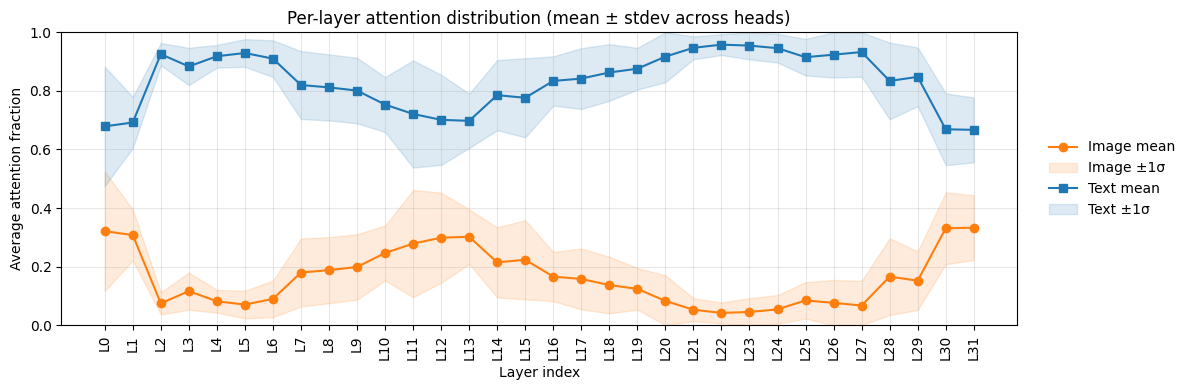

In [18]:
# Layer-wise mean/stdev of image vs text attention across heads
layer_indices = np.arange(head_image_data.shape[0])
layer_labels = [f"L{idx}" for idx in layer_indices]
layer_means_img = head_image_data.mean(axis=1)
layer_stds_img = head_image_data.std(axis=1)
layer_upper_img = np.clip(layer_means_img + layer_stds_img, 0.0, 1.0)
layer_lower_img = np.clip(layer_means_img - layer_stds_img, 0.0, 1.0)

layer_means_txt = head_text_data.mean(axis=1)
layer_stds_txt = head_text_data.std(axis=1)
layer_upper_txt = np.clip(layer_means_txt + layer_stds_txt, 0.0, 1.0)
layer_lower_txt = np.clip(layer_means_txt - layer_stds_txt, 0.0, 1.0)

plt.figure(figsize=(12, 4))
plt.plot(layer_indices, layer_means_img, color="tab:orange", marker="o", label="Image mean")
plt.fill_between(layer_indices, layer_lower_img, layer_upper_img, color="tab:orange", alpha=0.15, label="Image ±1σ")
plt.plot(layer_indices, layer_means_txt, color="tab:blue", marker="s", label="Text mean")
plt.fill_between(layer_indices, layer_lower_txt, layer_upper_txt, color="tab:blue", alpha=0.15, label="Text ±1σ")

plt.xticks(layer_indices, layer_labels, rotation=90)
plt.xlabel("Layer index")
plt.ylabel("Average attention fraction")
plt.ylim(0.0, 1.0)
plt.title("Per-layer attention distribution (mean ± stdev across heads)")
plt.grid(alpha=0.3)

# --- MODIFIED LEGEND ---
plt.legend(
    loc='center left', 
    bbox_to_anchor=(1.02, 0.5),  # Left edge of legend starts just past the plot
    ncol=1,                      # Stack items vertically
    frameon=False
)
# -----------------------

plt.tight_layout()
# bbox_inches='tight' ensures the outside legend isn't cut off when saving
plt.savefig("plots/attention_spread_layer_curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot Accuracy

In [19]:
mode = "visual" #  "image" or "text_only"
with open(f"evaluation_results_with_{mode}.json", "r") as f:
    evaluation_data = json.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'evaluation_results_with_visual.json'

In [ ]:
# Build DataFrames from the new evaluation_results.json structure
eval_rows = []
group_rows = []

for level_str, stats in evaluation_data.items():
    level = int(level_str)
    eval_rows.append({
        "level": level,
        "correct": stats.get("correct", 0),
        "total": stats.get("total", 0),
        "acc": stats.get("acc", 0.0),
    })

    by_group = stats.get("by_rel_group", {}) or {}
    for g_name, g_stats in by_group.items():
        group_rows.append({
            "level": level,
            "rel_group": g_name,
            "correct": g_stats.get("correct", 0),
            "total": g_stats.get("total", 0),
            "acc": g_stats.get("acc", 0.0),
        })

eval_df = pd.DataFrame(eval_rows).sort_values("level").reset_index(drop=True)
group_df = pd.DataFrame(group_rows).sort_values(["level", "rel_group"]).reset_index(drop=True)

# Labels for plotting
eval_df["level_label"] = eval_df["level"].apply(lambda k: f"level {k}")
if not group_df.empty:
    group_df["level_label"] = group_df["level"].apply(lambda k: f"level {k}")

eval_df.head()

,level,correct,total,acc,level_label
0,0,89,160,55.625000,level 0
1,1,102,160,63.750000,level 1
2,2,236,296,79.729730,level 2
3,3,691,920,75.108696,level 3
4,4,1347,1816,74.174009,level 4


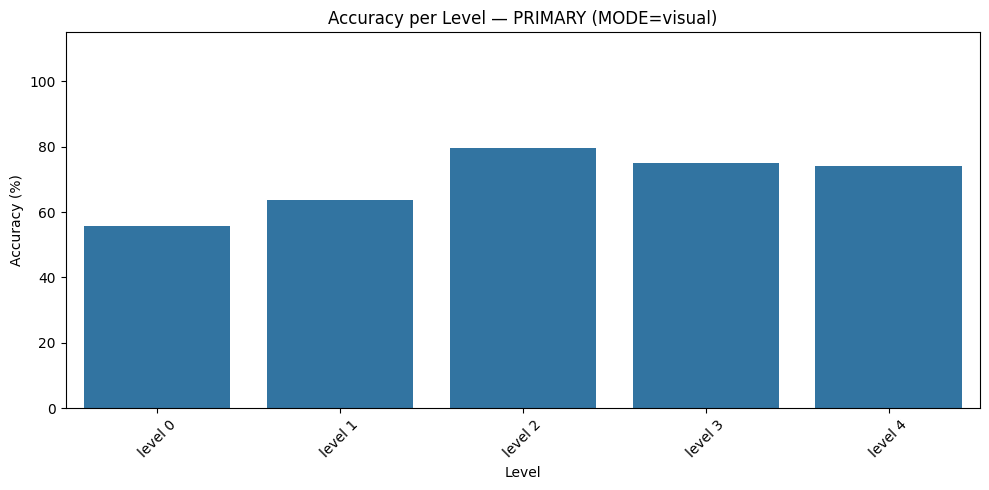

In [ ]:
# Plot 2a: PRIMARY
primary_df = group_df[group_df["rel_group"] == "PRIMARY"]

if not primary_df.empty:
    plt.figure(figsize=(10, 5))
    ax_p = sns.barplot(
        data=primary_df,
        x="level_label",
        y="acc"
    )

    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — PRIMARY (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"plots/accuracy_primary_{mode}.png")
    plt.show()
else:
    print("No PRIMARY data found")


In [ ]:
# Plot 2b: ADVANCED
advanced_df = group_df[group_df["rel_group"] == "ADVANCED"]

if not advanced_df.empty:
    plt.figure(figsize=(10, 5))
    ax_a = sns.barplot(
        data=advanced_df,
        x="level_label",
        y="acc"
    )


    plt.xlabel("Level")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Accuracy per Level — ADVANCED (MODE={mode})")
    plt.ylim(0, 115)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"plots/accuracy_advanced_{mode}.png")
    plt.show()
else:
    print("No ADVANCED data found")


No ADVANCED data found


In [ ]:
# Optional: view per-group table
group_df

,level,rel_group,correct,total,acc,level_label
0,0,PRIMARY,89,160,55.625000,level 0
1,1,PRIMARY,102,160,63.750000,level 1
2,2,PRIMARY,236,296,79.729730,level 2
3,3,PRIMARY,691,920,75.108696,level 3
4,4,PRIMARY,1347,1816,74.174009,level 4


# Reading Logs

In [ ]:
mode = "visual"
logs_df = pd.read_csv(f"./model_calls_log_with_{mode}.csv")
print(logs_df.head(5))
# print(list(logs_df[(logs_df["Model_Prediction"] == "no") & (logs_df["Ground_Truth"] == "yes")]['Prompt']))
mask = logs_df["Model_Prediction"].str.strip().str.lower() != logs_df["Ground_Truth"].str.strip().str.lower()
print(len(logs_df[mask]))

NameError: name 'pd' is not defined

In [ ]:
import textwrap

df_bad = logs_df[mask].reset_index(drop=True)

def wrap(s, width=110):
    return textwrap.fill("" if pd.isna(s) else str(s), width=width)

for i, row in enumerate(df_bad.itertuples(index=False), start=1):
    print("\n" + "=" * 120)
    gt = getattr(row, "Ground_Truth", "")
    pred = getattr(row, "Model_Prediction", "")
    conf = getattr(row, "Confidence", "")
    print(f"[{i}] GT={gt}  PRED={pred}  CONF={conf}")
    print("-" * 120)

    prompt = getattr(row, "Prompt", "")
    completion = getattr(row, "Completion", "")

    print("PROMPT:\n" + wrap(prompt))
    print("\nCOMPLETION:\n" + wrap(completion))

NameError: name 'logs_df' is not defined

In [ ]:
logs_df["Model_Prediction"].value_counts(dropna=False)

NameError: name 'logs_df' is not defined

In [ ]:
logs_df["Ground_Truth"].value_counts(dropna=False)

NameError: name 'logs_df' is not defined

## Plot Confusion Matrix

In [ ]:
def generate_confusion_matrix(csv_file, output_image=f'plots/confusion_matrix_{mode}.png'):
    # 1. Load the data
    df = pd.read_csv(csv_file)

    # 2. Clean and Normalize labels (handling whitespace/case)
    y_true = df['Ground_Truth'].str.strip().str.lower()
    y_pred = df['Model_Prediction'].str.strip().str.lower()

    # 3. Compute Confusion Matrix
    # We explicitly set labels to ensure the order is consistent
    labels = ['yes', 'no']
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # 4. Plotting using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted Yes', 'Predicted No'], 
                yticklabels=['Actual Yes', 'Actual No'])

    plt.title(f'VLM Relational Reasoning Confusion Matrix (MODE={mode})')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # 5. Save and Show
    plt.savefig(output_image, bbox_inches='tight', dpi=300)
    print(f"Confusion matrix saved to {output_image}")
    plt.show()

Confusion matrix saved to plots/confusion_matrix_visual.png


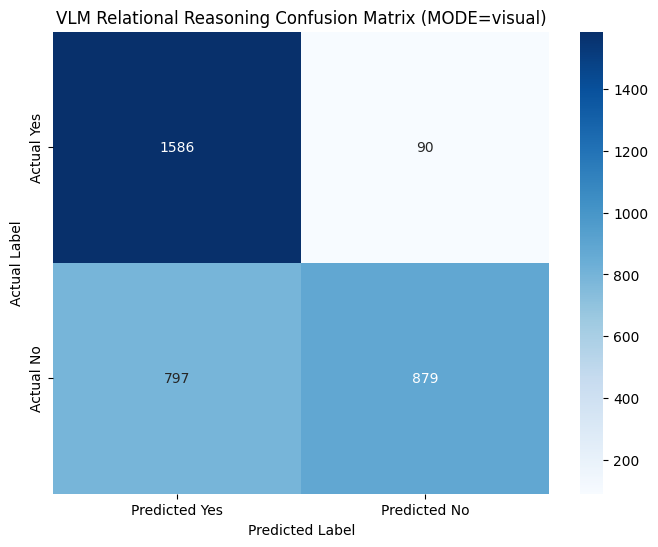

In [ ]:
generate_confusion_matrix(f"./model_calls_log_with_{mode}.csv")

In [ ]:
def plot_confusion_matrices_by_rel_type_grid(
    csv_file,
    rel_col="Rel_Type",
    labels=("yes", "no"),
    max_cols=3,
    output_image=None,
):
    # 1. Load and normalize labels
    df = pd.read_csv(csv_file).copy()
    df["_y_true"] = df["Ground_Truth"].astype(str).str.strip().str.lower()
    df["_y_pred"] = df["Model_Prediction"].astype(str).str.strip().str.lower()

    # 2. Build grouped relation type
    # touching + not_touching -> "touching"
    # inside + encapsulates   -> "inside_encapsulates"
    rel_raw = df[rel_col].astype(str).str.strip().str.lower()

    group_map = {
        "touching": "touching",
        "not_touching": "touching",
        "inside": "inside_encapsulates",
        "encapsulates": "inside_encapsulates",
        "overlapping": "overlapping",
        "not_overlapping": "overlapping"
    }

    df["_rel_group"] = rel_raw.map(group_map).fillna(rel_raw)

    # Drop rows that are empty after grouping
    df = df[df["_rel_group"].notna() & (df["_rel_group"] != "")]
    rel_types = sorted(df["_rel_group"].unique())
    n = len(rel_types)
    if n == 0:
        print("No valid relation types found.")
        return

    # 3. Prepare grid
    cols = min(max_cols, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    last_im = None
    for idx, rel in enumerate(rel_types):
        ax = axes_flat[idx]
        sub = df[df["_rel_group"] == rel]
        if sub.empty:
            ax.axis("off")
            continue

        cm = confusion_matrix(sub["_y_true"], sub["_y_pred"], labels=list(labels))

        im = sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[f"Pred {l}" for l in labels],
            yticklabels=[f"Actual {l}" for l in labels],
            cbar=False,
            ax=ax,
        )
        ax.set_title(rel)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        last_im = im

    # Turn off any unused axes
    for j in range(len(rel_types), len(axes_flat)):
        axes_flat[j].axis("off")

    fig.suptitle(f"Confusion Matrices by Rel_Type (grouped, MODE={mode})", y=1.02, fontsize=14)
    fig.tight_layout()

    if output_image is None:
        output_image = f"plots/confusion_matrices_by_{rel_col}_{mode}.png"
    os.makedirs(os.path.dirname(output_image), exist_ok=True)
    fig.savefig(output_image, bbox_inches="tight", dpi=300)
    print(f"Saved grouped grid figure to {output_image}")
    plt.show()

Saved grouped grid figure to plots/confusion_matrices_by_Rel_Group_visual.png


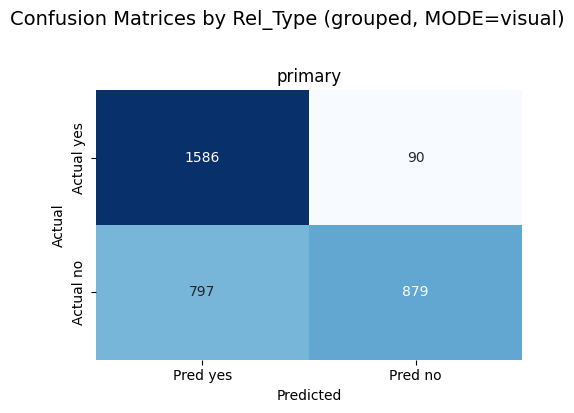

In [ ]:
plot_confusion_matrices_by_rel_type_grid(f"./model_calls_log_with_{mode}.csv", rel_col="Rel_Group")

Saved grouped grid figure to plots/confusion_matrices_by_Rel_Type_visual.png


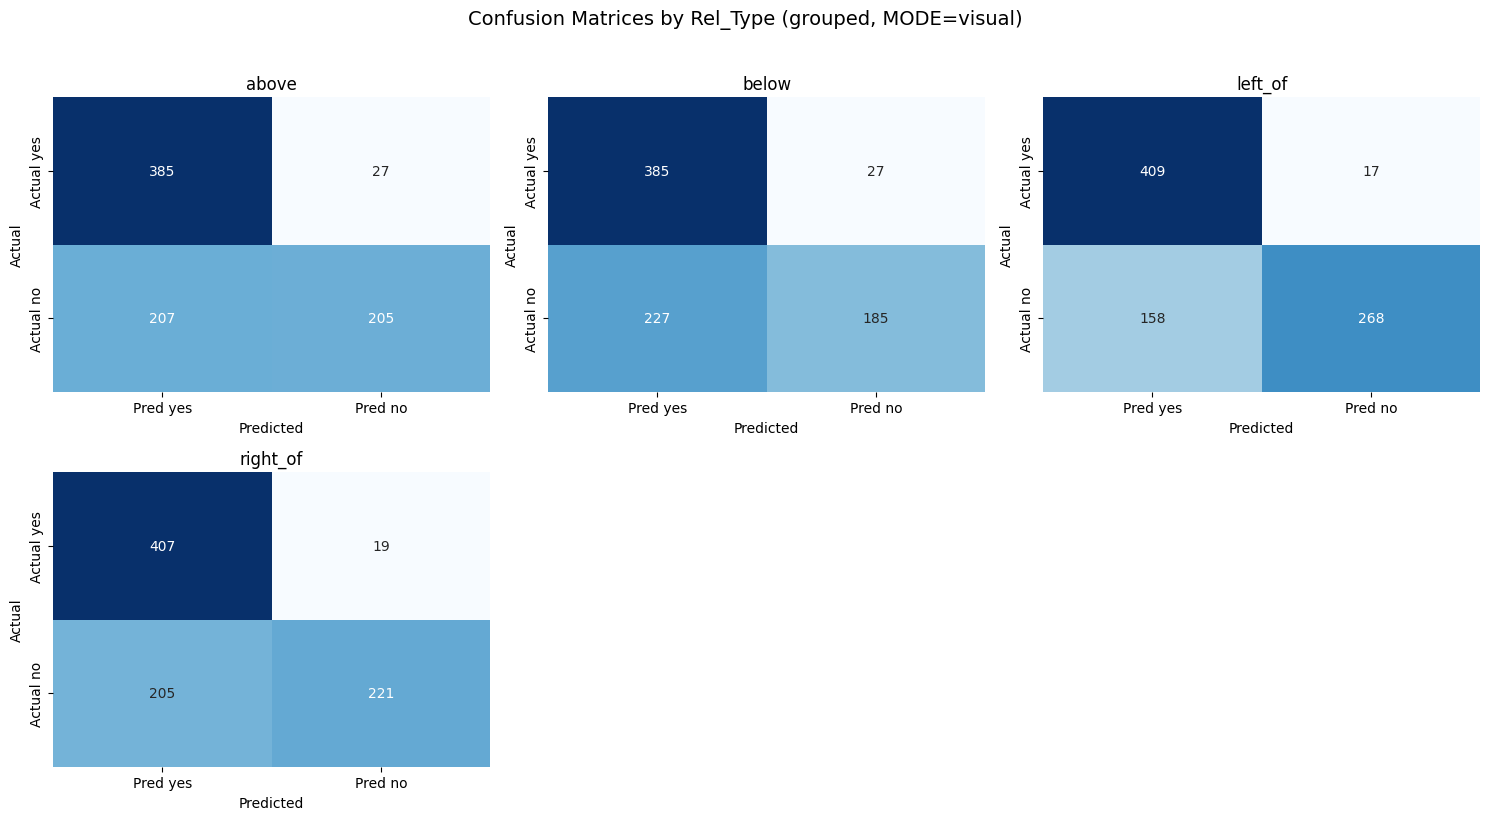

In [ ]:
plot_confusion_matrices_by_rel_type_grid(f"./model_calls_log_with_{mode}.csv")

In [ ]:
logs_df["y_true"] = (logs_df["Ground_Truth"].str.lower() == "yes").astype(int)
logs_df["y_prob"] = logs_df["P_Yes"].astype(float)
logs_df.head()

,Timestamp,Level,Image_Path,Rel_Group,Rel_Type,Prompt,Completion,Confidence,P_Yes,P_No,Ground_Truth,Model_Prediction,Result,Mode,y_true,y_prob
0,2025-12-30 20:14:17,0,/home/kkarthikeyan/deep-learning/DeepLearningP...,PRIMARY,above,[INST] <image>\nUse the spatial layout in the ...,Yes,0.542863,0.542863,0.457137,yes,yes,CORRECT,visual,1,0.542863
1,2025-12-30 20:14:18,0,/home/kkarthikeyan/deep-learning/DeepLearningP...,PRIMARY,below,[INST] <image>\nUse the spatial layout in the ...,Yes,0.577495,0.577495,0.422505,no,yes,INCORRECT,visual,0,0.577495
2,2025-12-30 20:14:19,0,/home/kkarthikeyan/deep-learning/DeepLearningP...,PRIMARY,below,[INST] <image>\nUse the spatial layout in the ...,Yes,0.709019,0.709019,0.290981,yes,yes,CORRECT,visual,1,0.709019
3,2025-12-30 20:14:19,0,/home/kkarthikeyan/deep-learning/DeepLearningP...,PRIMARY,above,[INST] <image>\nUse the spatial layout in the ...,Yes,0.615088,0.615088,0.384912,no,yes,INCORRECT,visual,0,0.615088
4,2025-12-30 20:14:20,0,/home/kkarthikeyan/deep-learning/DeepLearningP...,PRIMARY,left_of,[INST] <image>\nUse the spatial layout in the ...,No,0.503906,0.496094,0.503906,yes,no,INCORRECT,visual,1,0.496094


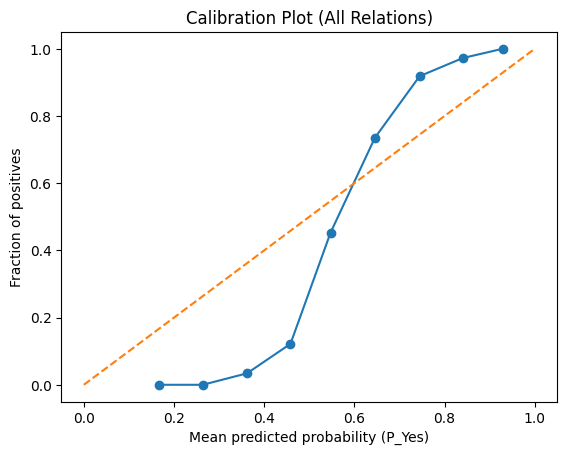

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    logs_df["y_true"],
    logs_df["y_prob"],
    n_bins=10,
    strategy="uniform"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Mean predicted probability (P_Yes)")
plt.ylabel("Fraction of positives")
plt.title("Calibration Plot (All Relations)")
plt.show()
